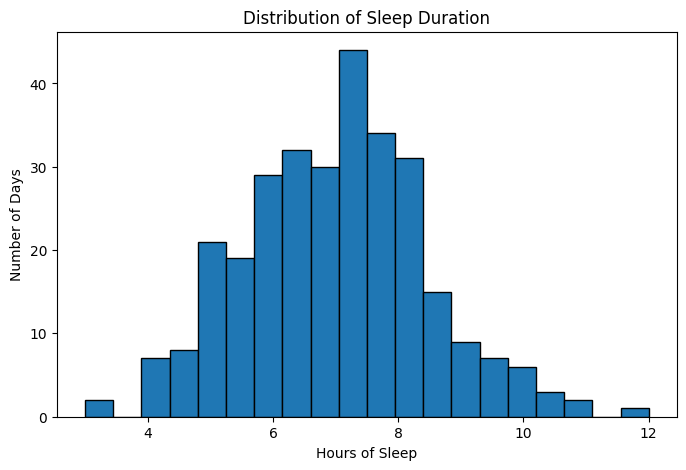


🔹 Linear Regression Results
Mean Squared Error: 207.03995879723087
R2 Score: -0.03511928470845471


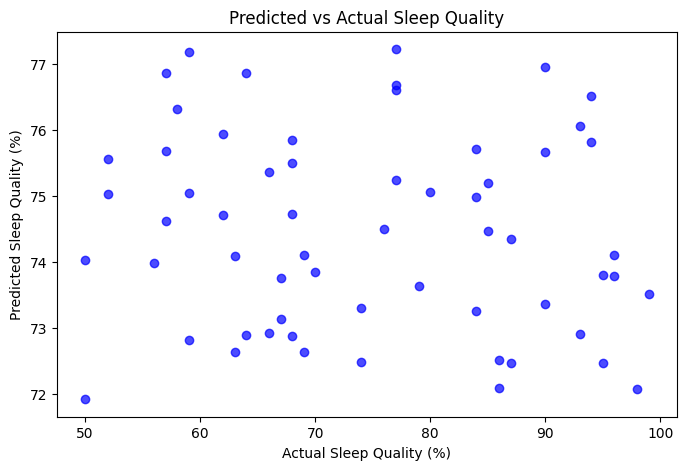


🔹 Cluster Centers (Good / Poor Sleepers):
[[5.80395213 1.86955736 1.53229706 3.04938272]
 [6.64498459 2.02387255 1.47185292 0.48739496]
 [8.36712664 1.98227942 1.52084904 2.93      ]]


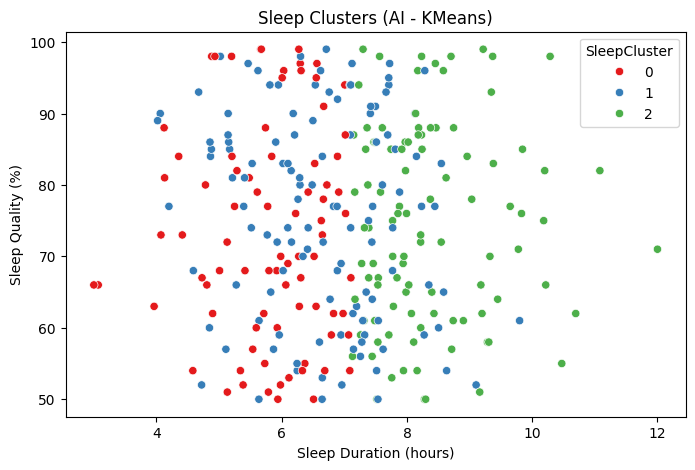

In [ ]:
# ===============================
# 1. Import libraries
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score

# ===============================
# 2. Load the Excel dataset
# ===============================
df = pd.read_excel("/content/sleep_data.xlsx")

# ===============================
# 3. Visualization (already explained earlier)
# ===============================
plt.figure(figsize=(8,5))
plt.hist(df["SleepDurationHours"], bins=20, edgecolor="black")
plt.title("Distribution of Sleep Duration")
plt.xlabel("Hours of Sleep")
plt.ylabel("Number of Days")
plt.show()

# ===============================
# 4. Machine Learning - Regression
# ===============================
# Goal: Predict Sleep Quality from Sleep Duration, Deep Sleep, REM, Awake Count

X = df[["SleepDurationHours", "DeepSleepHours", "REMHours", "AwakeCount"]]
y = df["SleepQuality"]

# Split data into train & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create & train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model performance
print("\n🔹 Linear Regression Results")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Plot predicted vs actual
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.7, color="blue")
plt.title("Predicted vs Actual Sleep Quality")
plt.xlabel("Actual Sleep Quality (%)")
plt.ylabel("Predicted Sleep Quality (%)")
plt.show()

# ===============================
# 5. AI - Clustering (K-Means)
# ===============================
# Goal: Group sleepers into clusters (good / poor sleepers)

features = df[["SleepDurationHours", "DeepSleepHours", "REMHours", "AwakeCount"]]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["SleepCluster"] = kmeans.fit_predict(features)

print("\n🔹 Cluster Centers (Good / Poor Sleepers):")
print(kmeans.cluster_centers_)

# Visualize clusters
plt.figure(figsize=(8,5))
sns.scatterplot(x="SleepDurationHours", y="SleepQuality", hue="SleepCluster", data=df, palette="Set1")
plt.title("Sleep Clusters (AI - KMeans)")
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Sleep Quality (%)")
plt.show()


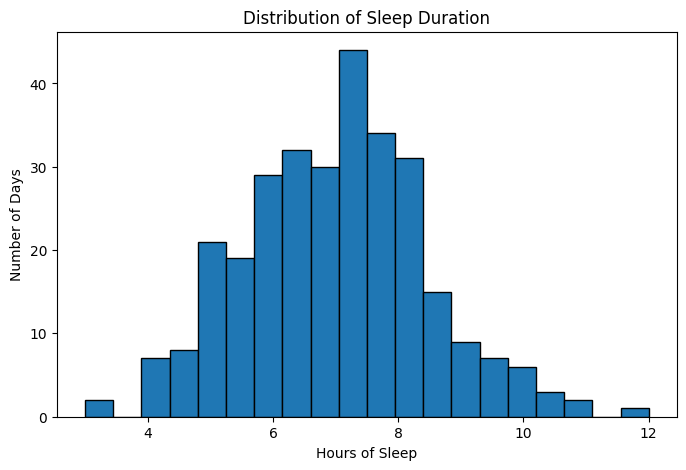


🔹 Linear Regression Results
Mean Squared Error: 207.03995879723087
R2 Score: -0.03511928470845471


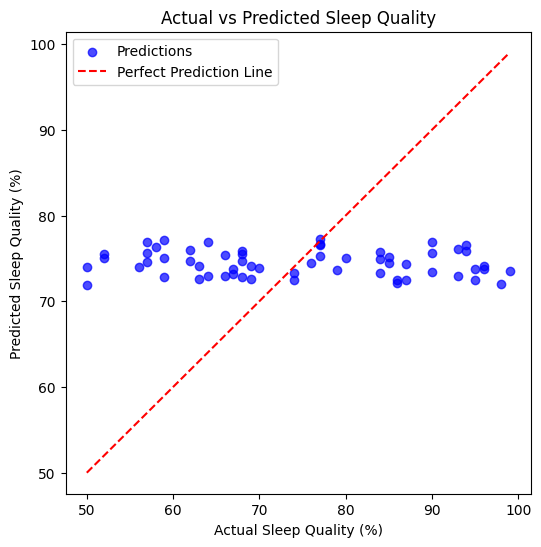


🔹 Cluster Centers (Good / Poor Sleepers):
[[5.80395213 1.86955736 1.53229706 3.04938272]
 [6.64498459 2.02387255 1.47185292 0.48739496]
 [8.36712664 1.98227942 1.52084904 2.93      ]]


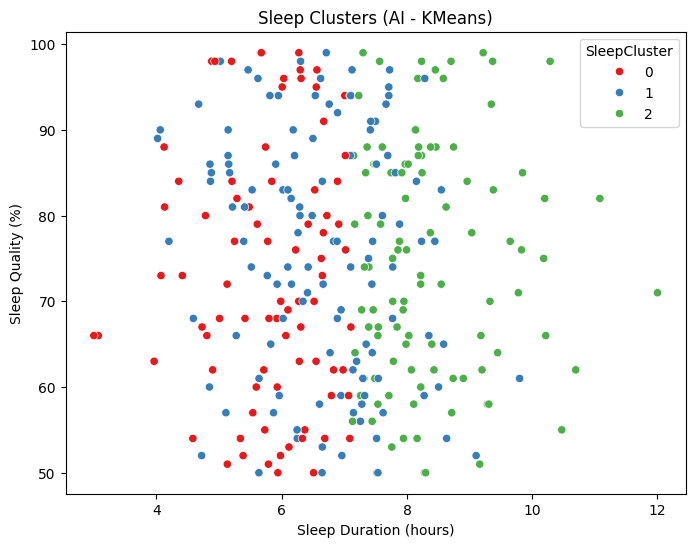

In [ ]:
# ===============================
# 1. Import libraries
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score

# ===============================
# 2. Load the Excel dataset
# ===============================
df = pd.read_excel("/content/sleep_data.xlsx")

# ===============================
# 3. Visualization Example
# ===============================
plt.figure(figsize=(8,5))
plt.hist(df["SleepDurationHours"], bins=20, edgecolor="black")
plt.title("Distribution of Sleep Duration")
plt.xlabel("Hours of Sleep")
plt.ylabel("Number of Days")
plt.show()

# ===============================
# 4. Machine Learning - Linear Regression
# ===============================
# Features (inputs) and Target (output)
X = df[["SleepDurationHours", "DeepSleepHours", "REMHours", "AwakeCount"]]
y = df["SleepQuality"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Performance
print("\n🔹 Linear Regression Results")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Actual vs Predicted Graph
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color="blue", alpha=0.7, label="Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linestyle="--", label="Perfect Prediction Line")
plt.title("Actual vs Predicted Sleep Quality")
plt.xlabel("Actual Sleep Quality (%)")
plt.ylabel("Predicted Sleep Quality (%)")
plt.legend()
plt.show()

# ===============================
# 5. AI - KMeans Clustering
# ===============================
features = df[["SleepDurationHours", "DeepSleepHours", "REMHours", "AwakeCount"]]

# Apply KMeans (3 clusters: Good, Average, Poor)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["SleepCluster"] = kmeans.fit_predict(features)

print("\n🔹 Cluster Centers (Good / Poor Sleepers):")
print(kmeans.cluster_centers_)

# Cluster Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(x="SleepDurationHours", y="SleepQuality",
                hue="SleepCluster", data=df, palette="Set1")
plt.title("Sleep Clusters (AI - KMeans)")
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Sleep Quality (%)")
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("sleep_data.xlsx")
print("Columns found:", df.columns)

# Try common column name options
duration_cols = ["SleepDuration", "Duration", "Hours", "sleep_duration"]
duration_col = next((c for c in duration_cols if c in df.columns), None)

if duration_col is None:
    raise ValueError("No Sleep Duration column found.")

before = df.copy()

# Cleaning
clean = df.copy()
clean = clean.drop_duplicates()
clean[duration_col] = clean[duration_col].replace(0, clean[duration_col].mean())
clean = clean[clean[duration_col] <= 12]

# HISTOGRAMS
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(before[duration_col], bins=15)
plt.title("Before Cleaning")
plt.xlabel("Sleep Duration (Hours)")

plt.subplot(1, 2, 2)
plt.hist(clean[duration_col], bins=15)
plt.title("After Cleaning")
plt.xlabel("Sleep Duration (Hours)")

plt.suptitle("Fig 3.2.1 – Duration Before & After Cleaning")
plt.tight_layout()
plt.show()


Columns found: Index(['UserID', 'Date', 'SleepDurationHours', 'SleepQuality',
       'DeepSleepHours', 'REMHours', 'AwakeCount', 'BedTime', 'WakeUpTime'],
      dtype='object')


ValueError: No Sleep Duration column found.

In [ ]:
#✅ BLOCK 1 — Load Data
import pandas as pd

df = pd.read_excel("/content/sleep_data.xlsx")
df.head()


,UserID,Date,SleepDurationHours,SleepQuality,DeepSleepHours,REMHours,AwakeCount,BedTime,WakeUpTime
0,1,2024-01-01,7.745071,85,1.996900,0.737992,3,03:00:00,04:00:00
1,2,2024-01-02,6.792604,59,2.201560,1.100780,2,05:00:00,11:00:00
2,3,2024-01-03,7.971533,86,2.561339,2.170656,4,09:00:00,00:00:00
3,4,2024-01-04,9.284545,58,1.279402,1.058111,1,06:00:00,22:00:00
4,5,2024-01-05,6.648770,73,1.938544,1.786983,4,12:00:00,04:00:00


In [ ]:
#✅ BLOCK 3 — Preprocessing (Raw vs Cleaned) (Fig 3.2.1)
df.head(10)

,UserID,Date,SleepDurationHours,SleepQuality,DeepSleepHours,REMHours,AwakeCount,BedTime,WakeUpTime
0,1,2024-01-01,7.745071,85,1.996900,0.737992,3,03:00:00,04:00:00
1,2,2024-01-02,6.792604,59,2.201560,1.100780,2,05:00:00,11:00:00
2,3,2024-01-03,7.971533,86,2.561339,2.170656,4,09:00:00,00:00:00
3,4,2024-01-04,9.284545,58,1.279402,1.058111,1,06:00:00,22:00:00
4,5,2024-01-05,6.648770,73,1.938544,1.786983,4,12:00:00,04:00:00
5,6,2024-01-06,6.648795,84,1.962348,0.623213,0,13:00:00,07:00:00
6,7,2024-01-07,9.368819,98,1.449374,2.540657,2,03:00:00,12:00:00
7,8,2024-01-08,8.151152,84,2.243837,1.347723,1,07:00:00,07:00:00
8,9,2024-01-09,6.295788,97,2.373684,1.547660,3,04:00:00,22:00:00
9,10,2024-01-10,7.813840,85,1.854654,1.589518,1,00:00:00,10:00:00


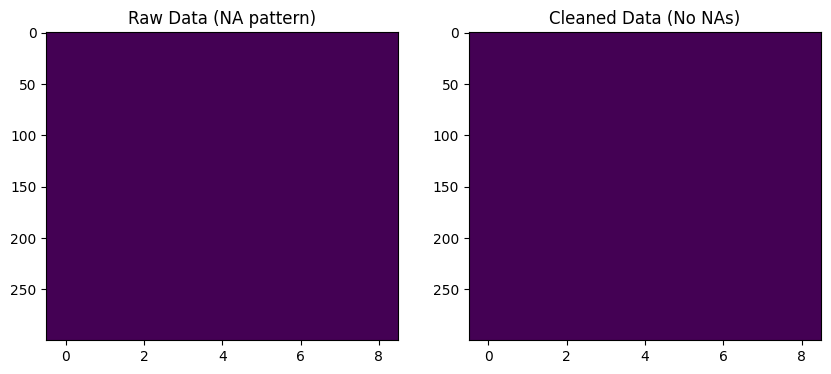

In [ ]:
#✅ BLOCK 3 — Preprocessing (Raw vs Cleaned) (Fig 3.2.1)
import matplotlib.pyplot as plt

raw = df.copy()

# Cleaning example
df_clean = df.dropna().reset_index(drop=True)

fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].imshow(raw.isna(), aspect='auto')
ax[0].set_title("Raw Data (NA pattern)")
ax[1].imshow(df_clean.isna(), aspect='auto')
ax[1].set_title("Cleaned Data (No NAs)")
plt.show()


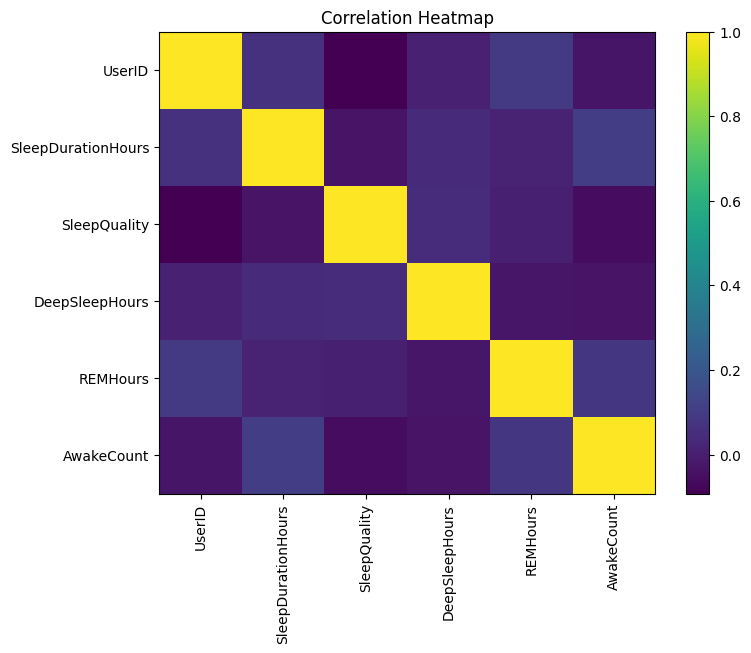

In [ ]:
#✅ BLOCK 4 — Correlation Heatmap (Fig 3.2.4.1)
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df_clean.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.title("Correlation Heatmap")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.show()



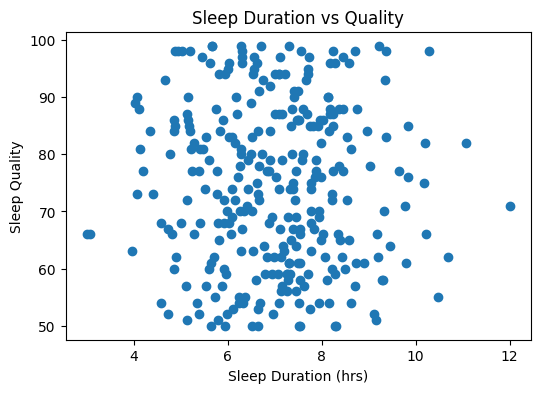

In [ ]:
#✅ BLOCK 5 — Scatter Plot: Sleep vs Quality (Fig 3.2.4.3)
plt.figure(figsize=(6,4))
plt.scatter(df_clean['SleepDurationHours'], df_clean['SleepQuality'])
plt.xlabel("Sleep Duration (hrs)")
plt.ylabel("Sleep Quality")
plt.title("Sleep Duration vs Quality")
plt.show()


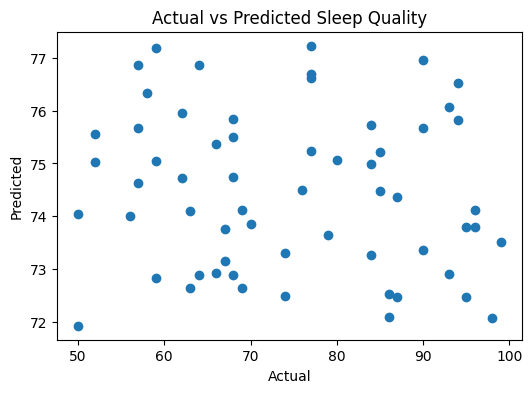

In [ ]:
#✅ BLOCK 6 — Regression Model + Actual vs Predicted (Fig 3.2.2.1 & 3.5.1)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df_clean[['SleepDurationHours','DeepSleepHours','REMHours','AwakeCount']]
y = df_clean['SleepQuality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Sleep Quality")
plt.show()


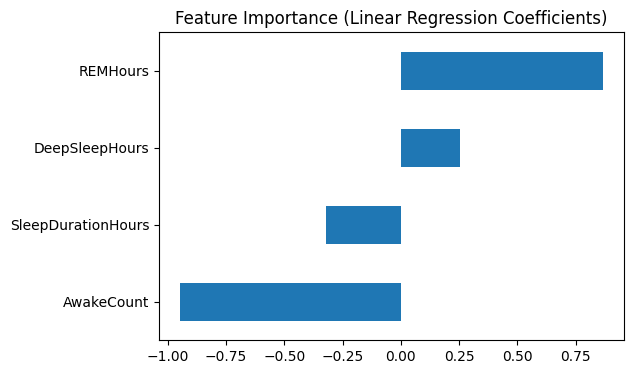

In [ ]:
#✅ BLOCK 7 — Feature Importance (Fig 3.4.1)
importance = pd.Series(model.coef_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(6,4))
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.show()


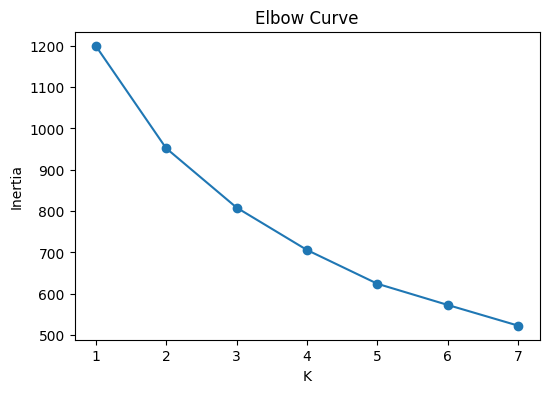

In [ ]:
# BLOCK 8 — Elbow Curve (K-Means) (Fig 3.2.2.2)

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaled = StandardScaler().fit_transform(X)

inertias = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 8), inertias, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Curve")
plt.show()



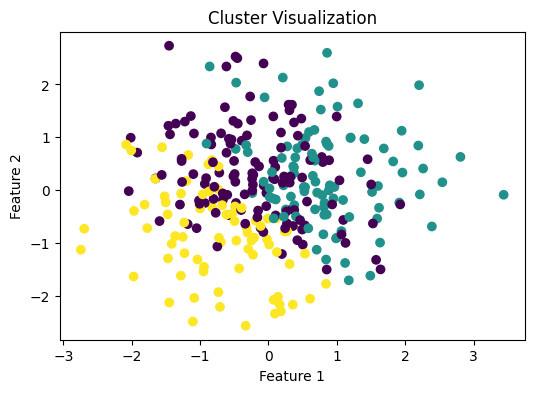

In [ ]:
# BLOCK 9 — Cluster Plot (Fig 3.2.2.3 & 3.5.2)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Ensure scaled exists
# scaled = StandardScaler().fit_transform(X)

km = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = km.fit_predict(scaled)

plt.figure(figsize=(6,4))
plt.scatter(scaled[:, 0], scaled[:, 1], c=clusters)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Cluster Visualization")
plt.show()


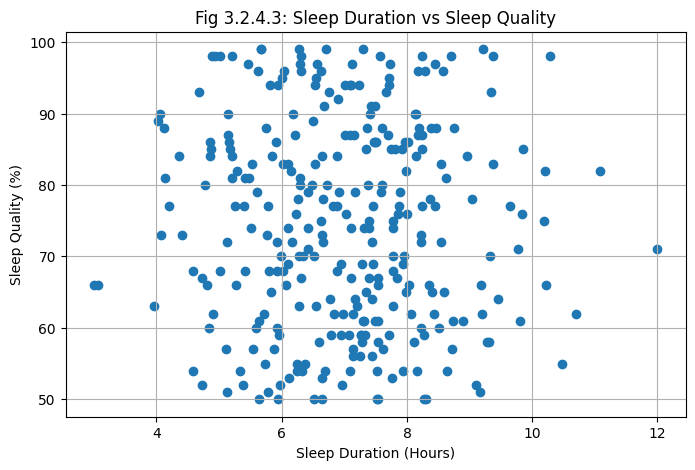

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("sleep_data.xlsx")

# Plot
plt.figure(figsize=(8,5))
plt.scatter(df["SleepDurationHours"], df["SleepQuality"])
plt.title("Fig 3.2.4.3: Sleep Duration vs Sleep Quality")
plt.xlabel("Sleep Duration (Hours)")
plt.ylabel("Sleep Quality (%)")
plt.grid(True)
plt.show()


5th

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-2770322.py:16: SyntaxWarning: invalid escape sequence '\m'
  "Implementation\n(Preprocessing\n ML\m LLM)",


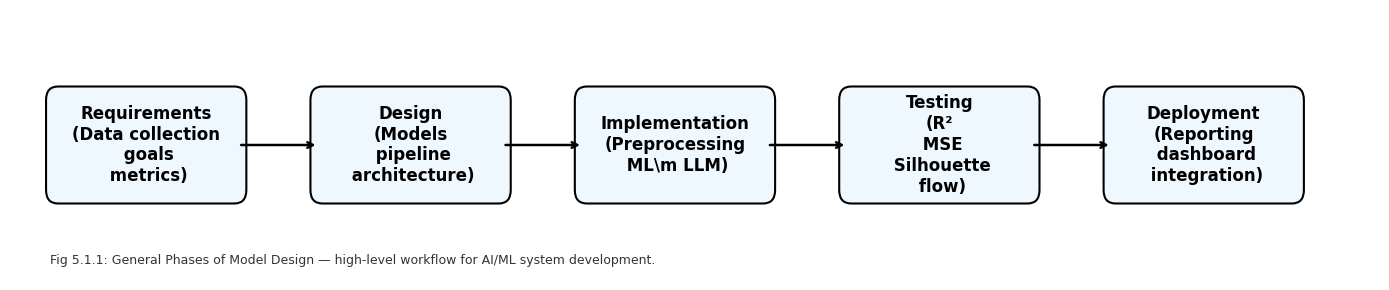

Saved diagram to: /mnt/data/model_design_phases.png


In [ ]:
# Fig 5.1.1: General Phases of Model Design
# Draws a simple workflow diagram: Requirements -> Design -> Implementation -> Testing -> Deployment
# Saves output to /mnt/data/model_design_phases.png

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

output_path = "/mnt/data/model_design_phases.png"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Diagram settings
phases =  [
    "Requirements\n(Data collection\n goals\n metrics)",
    "Design\n(Models\n pipeline\n architecture)",
    "Implementation\n(Preprocessing\n ML\m LLM)",
    "Testing\n(R²\n MSE\n Silhouette\n flow)",
    "Deployment\n(Reporting\n dashboard\n integration)"
]

n = len(phases)
fig_w = 14
fig_h = 3
box_w = 2.2
box_h = 1.0
x_start = 0.6
y_center = 1.5
x_gap = 2.2

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.set_xlim(0, x_start + n * (box_w + x_gap/2))
ax.set_ylim(0, 3)
ax.axis('off')

# Draw boxes with rounded corners and text
for i, label in enumerate(phases):
    x = x_start + i * (box_w + x_gap/2)
    box = patches.FancyBboxPatch(
        (x, y_center - box_h/2),
        box_w, box_h,
        boxstyle="round,pad=0.15",
        linewidth=1.5,
        edgecolor="black",
        facecolor="#f0f8ff"
    )
    ax.add_patch(box)
    ax.text(x + box_w/2, y_center, label, ha='center', va='center', fontsize=12, weight='semibold')

# Draw arrows between boxes
for i in range(n - 1):
    x_from = x_start + i * (box_w + x_gap/2) + box_w
    x_to = x_start + (i+1) * (box_w + x_gap/2)
    y = y_center
    ax.annotate(
        "",
        xy=(x_to - 0.05, y),
        xytext=(x_from + 0.05, y),
        arrowprops=dict(arrowstyle="->", lw=1.8, color="black"),
    )

# Add a subtitle / caption area
ax.text(0.5, 0.22,
        "Fig 5.1.1: General Phases of Model Design — high-level workflow for AI/ML system development.",
        fontsize=9, ha='left', va='center', alpha=0.8)

fig.tight_layout()
fig.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()

print("Saved diagram to:", output_path)


/tmp/ipython-input-3195768021.py:95: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


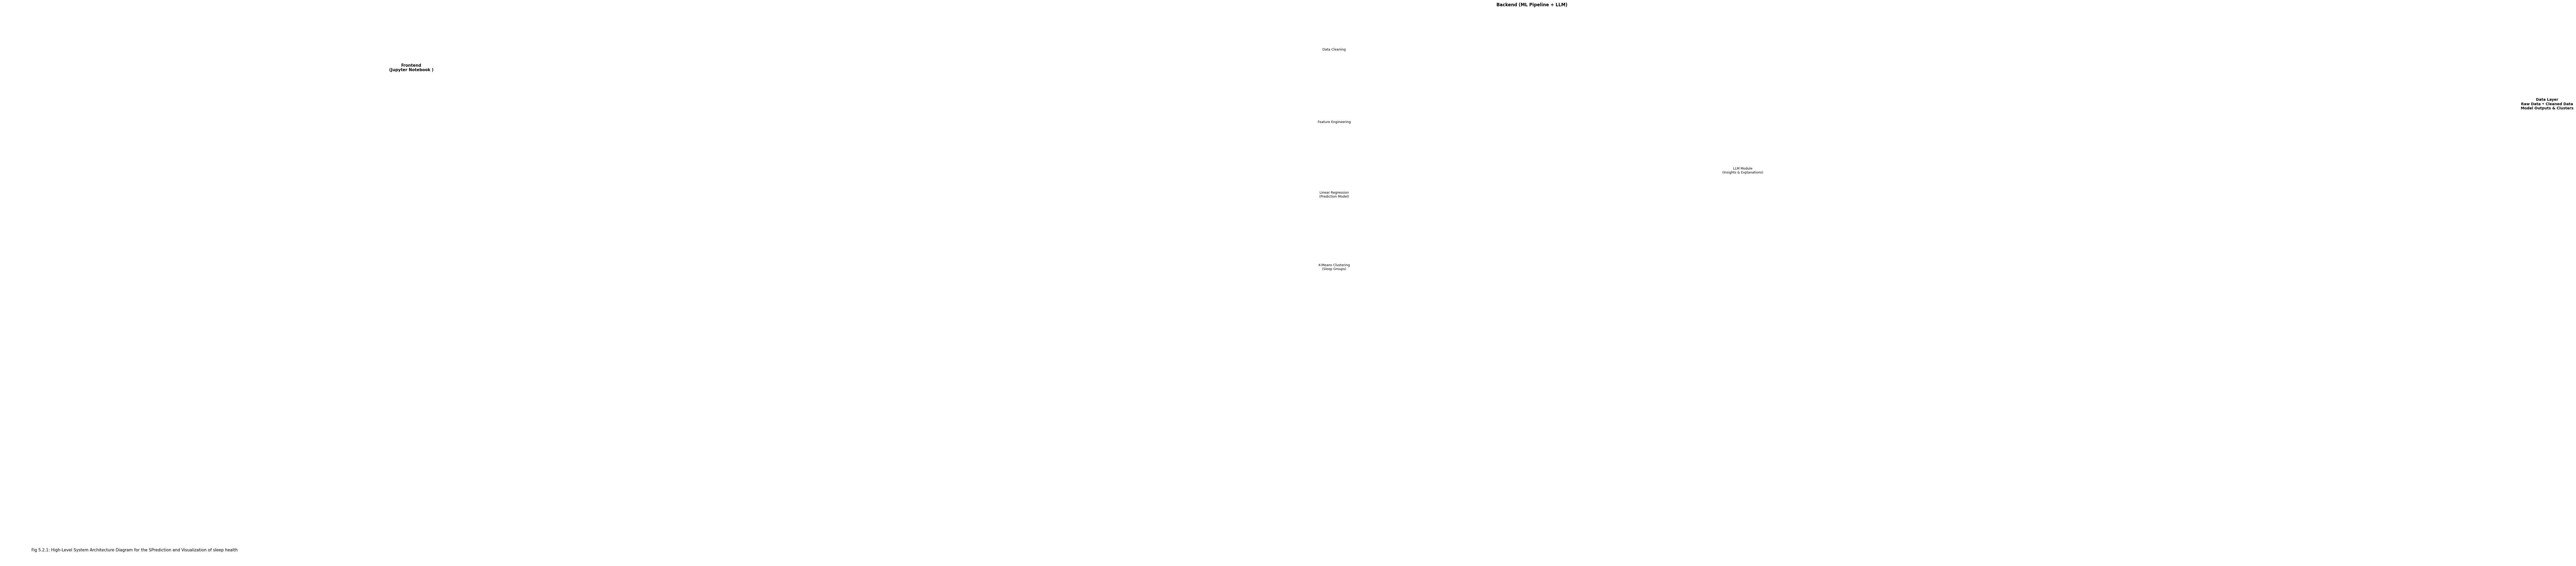

Saved diagram to: /mnt/data/system_architecture_diagram.png


In [ ]:
# Fig 5.2.1 - High-Level System Architecture Diagram
# Customized specifically for the Sleep Health Prediction System (sleep.ipynb)

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

output_path = "/mnt/data/system_architecture_diagram.png"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

fig, ax = plt.subplots(figsize=(13, 6))
ax.axis("off")

# --- Block Positions ---
frontend_x, frontend_y = 0.4, 3.4
backend_x, backend_y = 4.1, 1.9
data_x, data_y = 8.4, 3.1

# --- Frontend ---
frontend = patches.FancyBboxPatch(
    (frontend_x, frontend_y), 2.3, 1.4,
    boxstyle="round,pad=0.25", linewidth=1.5,
    edgecolor="black", facecolor="#e3f2fd"
)
ax.add_patch(frontend)
ax.text(frontend_x + 1.15, frontend_y + 0.7,
        "Frontend\n(Jupyter Notebook )",
        ha="center", va="center", fontsize=11, weight='bold')

# --- Backend ---
backend = patches.FancyBboxPatch(
    (backend_x, backend_y), 3.4, 3.0,
    boxstyle="round,pad=0.25", linewidth=1.5,
    edgecolor="black", facecolor="#fff3e0"
)
ax.add_patch(backend)
ax.text(backend_x + 1.7, backend_y + 2.7,
        "Backend (ML Pipeline + LLM)",
        ha="center", va="bottom", fontsize=12, weight='bold')


# --- Backend Submodules (Customized for sleep.ipynb) ---
submodules = [
    ("Data Cleaning", backend_x + 0.25, backend_y + 2.0),
    ("Feature Engineering", backend_x + 0.25, backend_y + 1.4),
    ("Linear Regression\n(Prediction Model)", backend_x + 0.25, backend_y + 0.8),
    ("K-Means Clustering\n(Sleep Groups)", backend_x + 0.25, backend_y + 0.2),
    ("LLM Module\n(Insights & Explanations)", backend_x + 1.8, backend_y + 1.0)
]

for label, x, y in submodules:
    box = patches.FancyBboxPatch(
        (x, y), 1.4, 0.7,
        boxstyle="round,pad=0.2", linewidth=1.2,
        edgecolor="black", facecolor="white"
    )
    ax.add_patch(box)
    ax.text(x + 0.7, y + 0.35, label,
            ha="center", va="center", fontsize=9)

# --- Data Layer ---
data_layer = patches.FancyBboxPatch(
    (data_x, data_y), 2.5, 1.4,
    boxstyle="round,pad=0.25", linewidth=1.5,
    edgecolor="black", facecolor="#e8f5e9"
)
ax.add_patch(data_layer)
ax.text(data_x + 1.25, data_y + 0.7,
        "Data Layer\nRaw Data • Cleaned Data\nModel Outputs & Clusters",
        ha="center", va="center", fontsize=10, weight='bold')

# --- Arrows ---
arrow_style = dict(arrowstyle="->", lw=2.0, color="black")

# Frontend → Backend
ax.annotate("", xy=(backend_x, frontend_y + 0.7),
            xytext=(frontend_x + 2.3, frontend_y + 0.7),
            arrowprops=arrow_style)

# Backend → Data Layer
ax.annotate("", xy=(data_x, backend_y + 1.5),
            xytext=(backend_x + 3.4, backend_y + 1.5),
            arrowprops=arrow_style)

# Frontend ↔ Data Layer (optional reading of results)
ax.annotate("", xy=(frontend_x + 2.3, frontend_y + 0.3),
            xytext=(data_x, data_y + 0.3),
            arrowprops=dict(arrowstyle="<->", lw=1.6, color="gray"))

# Caption
ax.text(0.5, 0.1,
        "Fig 5.2.1: High-Level System Architecture Diagram for the SPrediction and Visualization of sleep health",
        fontsize=11, ha='center')

plt.tight_layout()
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved diagram to:", output_path)
